## Credit Card Default Prediction Using Machine Learning

##### This project aims to predict whether a credit card customer will default on their payment next month using machine learning models.

##### The dataset contains customer demographic information, credit limit details, and past payment history.

##### Machine learning models such as Logistic Regression and Decision Trees are used to predict the likelihood of default.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

## 1. Problem Statement

##### The goal of this project is to predict whether a credit card customer will default on their payment in the next month.

##### Credit card default occurs when a customer fails to make the required payment on their credit card balance. Predicting potential defaulters can help financial institutions manage risk and take preventive measures.

##### This is a binary classification problem where the model predicts whether a customer will default (1) or not default (0) based on demographic information, credit limit, and past payment history.

## 2. Dataset Overview

##### The dataset used in this project is the Credit Card Default dataset. It contains information about credit card clients including demographic features, credit limits, bill amounts, and past payment history.

##### The target variable indicates whether the customer will default on their payment in the next month.

In [2]:
df = pd.read_csv("UCI_Credit_Card.csv")

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.shape

(30000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
df['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

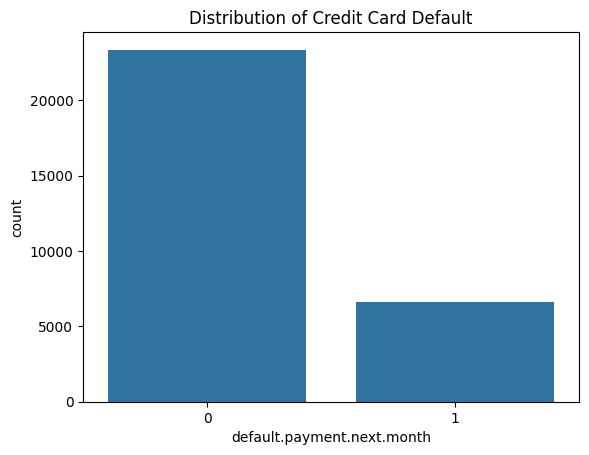

In [7]:
sns.countplot(x='default.payment.next.month', data=df)
plt.title("Distribution of Credit Card Default")
plt.show()

#Observation:
#The dataset is imbalanced, with significantly more customers who did not default compared to those who defaulted.
#This indicates a class imbalance problem which may affect model training.

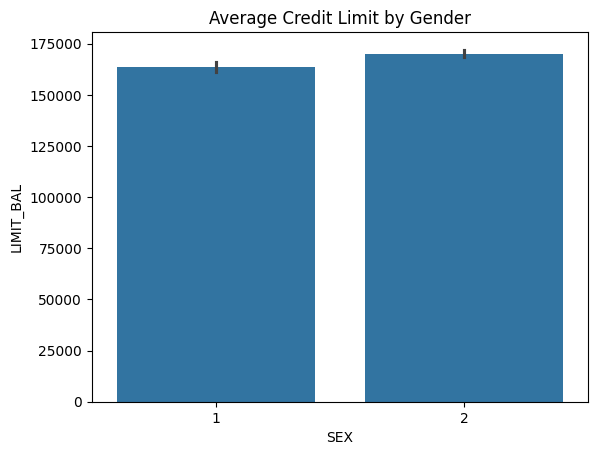

In [8]:
sns.barplot(x='SEX', y='LIMIT_BAL', data=df)
plt.title("Average Credit Limit by Gender")
plt.show()

#Observation:
#Customers with SEX = 2 have a slightly higher average credit limit compared to customers with SEX = 1.
#However, the difference is not very large, suggesting gender alone may not strongly influence credit limit allocation.

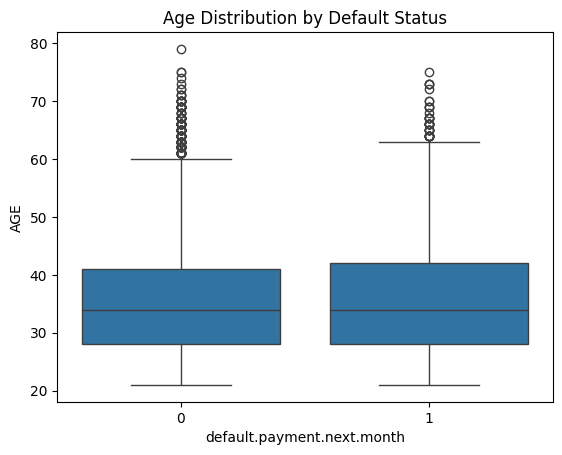

In [9]:
sns.boxplot(y='AGE', x='default.payment.next.month', data=df)
plt.title("Age Distribution by Default Status")
plt.show()

#Observation:
#The median age for both defaulters and non-defaulters appears to be quite similar.
#There is significant overlap in the age distributions, indicating that age alone may not be a strong predictor of default.
#Some outliers exist for older age groups in both categories.


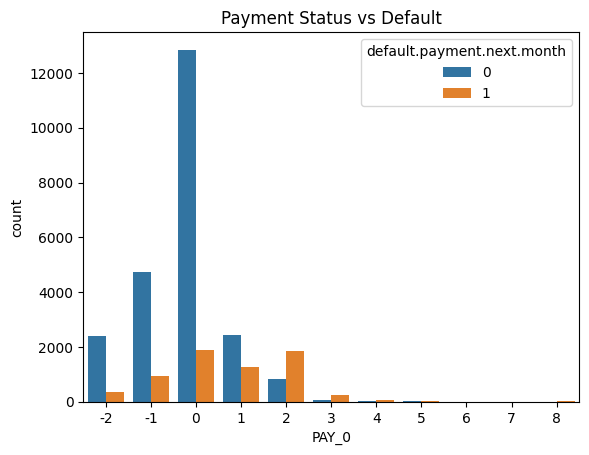

In [10]:
sns.countplot(x='PAY_0', hue='default.payment.next.month', data=df)
plt.title("Payment Status vs Default")
plt.show()

#Observation:
#Customers with no payment delay (PAY_0 = 0) form the majority of non-default cases.
#As payment delay increases (PAY_0 ≥ 1), the proportion of defaulters increases.
#This suggests that recent payment history is strongly associated with default risk.


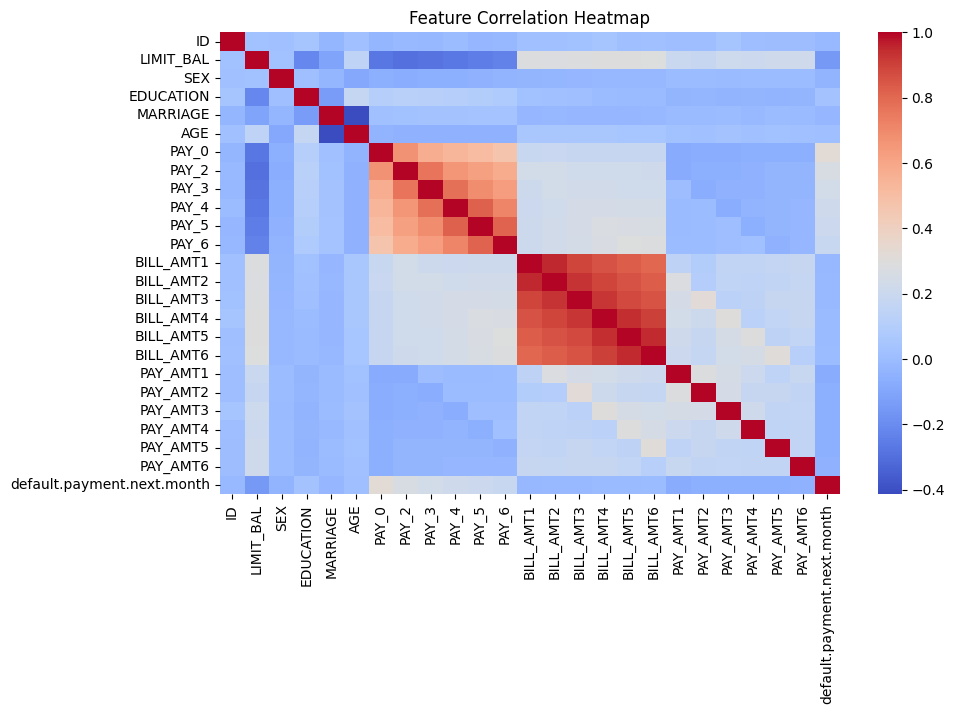

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

#Observation:

#Payment status variables (PAY_0, PAY_2, PAY_3, etc.) appear to be moderately correlated with each other, indicating similar behavior across months.
#Bill amount variables (BILL_AMT1 to BILL_AMT6) also show strong correlations, which is expected since they represent consecutive monthly bills.
#The target variable (default.payment.next.month) shows some correlation with payment status features, suggesting they may be useful predictors in the model.


## Data Preprocessing

In [12]:
df.drop('ID', axis=1, inplace=True)

X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#The dataset is split into training and testing sets. 
#The training set is used to train the model, while the test set is used to evaluate model performance.

In [14]:
#EncodingAndScaling

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
all_numeric_cols = X_train.select_dtypes(include = ['int64', 'float64']).columns

numeric_cols = []
for col in all_numeric_cols:
    if col not in categorical_cols:
        numeric_cols.append(col)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

#Categorical variables such as SEX, EDUCATION, and MARRIAGE are encoded using OneHotEncoder.

#Numerical features are scaled using StandardScaler to normalize their values.

#A ColumnTransformer is used to apply different preprocessing steps to categorical and numerical features simultaneously. 
#This ensures consistent preprocessing during both training and testing.

## Model Prediction

### Logistic Regression

In [15]:
model_bal = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_bal.fit(X_train_encoded, y_train)
y_pred_bal = model_bal.predict(X_test_encoded)

## Model Evaluation

In [16]:
print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

[[3294 1393]
 [ 459  854]]
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4687
           1       0.38      0.65      0.48      1313

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.71      6000



### Tuning Threshold

In [17]:
y_prob = model_bal.predict_proba(X_test_encoded)[:, 1]

y_pred_05 = (y_prob >= 0.5).astype(int)
y_pred_04 = (y_prob >= 0.4).astype(int)
y_pred_03 = (y_prob >= 0.3).astype(int)

In [18]:
print("Threshold 0.3")
print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))

Threshold 0.3
[[1027 3660]
 [ 130 1183]]
              precision    recall  f1-score   support

           0       0.89      0.22      0.35      4687
           1       0.24      0.90      0.38      1313

    accuracy                           0.37      6000
   macro avg       0.57      0.56      0.37      6000
weighted avg       0.75      0.37      0.36      6000



In [19]:
#Logistic regression outputs probabilities. By adjusting the decision threshold, we can control the trade-off between precision and recall.

#Lowering the threshold increases recall, allowing the model to identify more potential defaulters.

## Decision Tree

In [20]:
dt_ctrl = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_leaf=50
)

dt_ctrl.fit(X_train_encoded, y_train)

y_pred_dt = dt_ctrl.predict(X_test_encoded)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[4431  256]
 [ 833  480]]
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.65      0.37      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.75      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



In [21]:
##Observation:

#Lowering the classification threshold from 0.5 to 0.3 increases the recall for the default class. 
#This allows the model to detect more potential defaulters.

#In financial risk prediction, missing a defaulter can be costly, so improving recall for the default class is important.

### ROC Curve

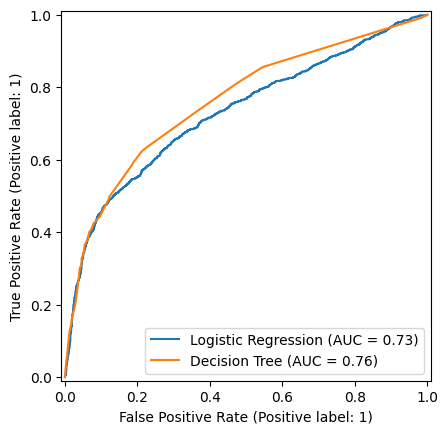

In [22]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots()

# Logistic Regression
RocCurveDisplay.from_estimator(
    model_bal,
    X_test_encoded,
    y_test,
    ax=ax,
    name="Logistic Regression"
)

# Decision Tree
RocCurveDisplay.from_estimator(
    dt_ctrl,
    X_test_encoded,
    y_test,
    ax=ax,
    name="Decision Tree"
)

plt.show()

In [23]:
#The ROC curve shows the trade-off between the true positive rate and the false positive rate at different classification thresholds.
#A curve closer to the top-left corner indicates better model performance.
#The decision tree model provides a different trade-off between true positives and false positives.
#Comparing ROC curves helps identify which model better separates defaulters from non-defaulters.

In [24]:
import joblib

joblib.dump(dt_ctrl, "credit_default_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']